In [2]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Install/Import official CLIP
try:
    import clip
except ImportError:
    !pip install git+https://github.com/openai/CLIP.git
    import clip

# Load OpenAI's official ViT-B/32 CLIP model
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# 2. Download STL-10 Test Set (8,000 images, 10 classes)
# Points to the root data folder
stl10_test = datasets.STL10(root='../data', split='test', download=True, transform=preprocess)
test_loader = DataLoader(stl10_test, batch_size=128, shuffle=False, num_workers=2)

classes = stl10_test.classes
print(f"STL-10 Classes: {classes}")
print(f"Total test images: {len(stl10_test)}")

Using device: cuda
Using downloaded and verified file: ../data\stl10_binary.tar.gz
Extracting ../data\stl10_binary.tar.gz to ../data
STL-10 Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Total test images: 8000


Encoding text prompts...
Running inference on 8,000 images...


Evaluating Zero-Shot CLIP: 100%|██████████| 63/63 [00:30<00:00,  2.04it/s]



--- Zero-Shot Accuracies ---
plain_label: 96.26%
a_photo_of: 97.31%
low_res_descriptive: 95.61%
template_ensemble: 97.08%


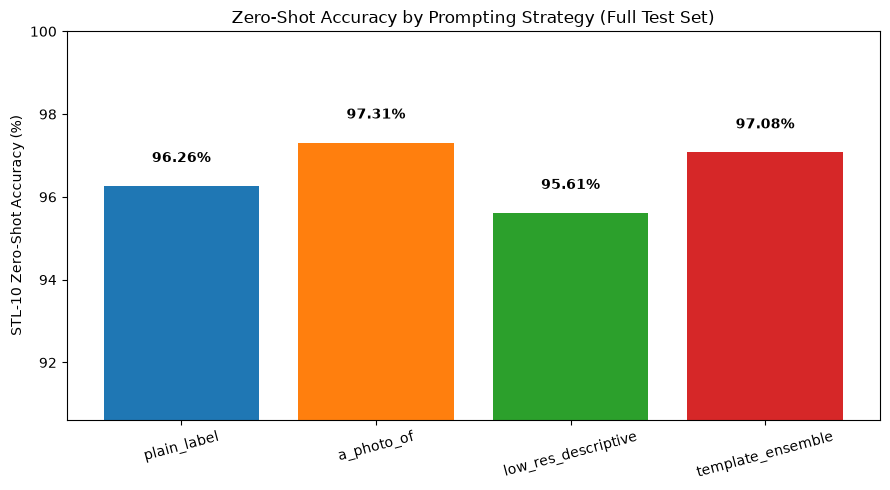

In [3]:
import torch

# 1. Define Prompting Strategies
templates = {
    "plain_label": "{}",
    "a_photo_of": "a photo of a {}.",
    "low_res_descriptive": "a low resolution photo of a small {}.",
}

# Ensemble templates (a standard robust zero-shot setup)
ensemble_templates = [
    "a photo of a {}.",
    "a bad photo of a {}.",
    "a photo of many {}.",
    "a sculpture of a {}.",
    "a photo of the hard to see {}.",
    "a low resolution photo of the {}."
]

def get_text_features(class_names, template_dict, ensemble_list):
    strategy_features = {}
    with torch.no_grad():
        # Process Single Templates
        for name, template in template_dict.items():
            texts = [template.format(c) for c in class_names]
            tokens = clip.tokenize(texts).to(device)
            features = model.encode_text(tokens)
            features /= features.norm(dim=-1, keepdim=True)
            strategy_features[name] = features
            
        # Process Template Ensemble
        ensemble_feats = []
        for c in class_names:
            texts = [t.format(c) for t in ensemble_list]
            tokens = clip.tokenize(texts).to(device)
            features = model.encode_text(tokens)
            features /= features.norm(dim=-1, keepdim=True)
            # Average the embeddings for this specific class across all templates
            mean_features = features.mean(dim=0)
            mean_features /= mean_features.norm(dim=-1, keepdim=True)
            ensemble_feats.append(mean_features)
            
        strategy_features["template_ensemble"] = torch.stack(ensemble_feats)
        
    return strategy_features

print("Encoding text prompts...")
text_features_dict = get_text_features(classes, templates, ensemble_templates)

# 2. Evaluate Zero-Shot Accuracy
def evaluate_zero_shot(loader, text_features_dict):
    correct_counts = {name: 0 for name in text_features_dict.keys()}
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating Zero-Shot CLIP"):
            images = images.to(device)
            labels = labels.to(device)
            
            # Extract and normalize image features
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            # Compute similarities for each strategy
            for name, text_features in text_features_dict.items():
                # Cosine similarity matrix multiplication
                similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
                preds = similarity.argmax(dim=-1)
                correct_counts[name] += (preds == labels).sum().item()
                
            total += images.size(0)
            
    accuracies = {name: count / total for name, count in correct_counts.items()}
    return accuracies

print("Running inference on 8,000 images...")
accuracies = evaluate_zero_shot(test_loader, text_features_dict)

# 3. Print and Plot Results
print("\n--- Zero-Shot Accuracies ---")
for name, acc in accuracies.items():
    print(f"{name}: {acc*100:.2f}%")

names = list(accuracies.keys())
acc_values = [acc * 100 for acc in accuracies.values()]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, acc_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim(min(acc_values) - 5, 100)
plt.ylabel('STL-10 Zero-Shot Accuracy (%)')
plt.title('Zero-Shot Accuracy by Prompting Strategy (Full Test Set)')
plt.xticks(rotation=15)

# Add exact percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# Save directly to your figures folder!
plt.savefig('../report/figures/task3_zero_shot.png', dpi=300)
plt.show()

Modality Gap (Centroid Distance) BEFORE alignment: 1.0449


C:\Users\mahad\AppData\Local\Temp\ipykernel_13384\2726728517.py:39: DeprecationWarning: Calling orthogonal_procrustes with arguments of dtype=float16 (a.dtype.char = 'e') is deprecated in SciPy 1.18.0 and will be removed in SciPy 1.20.0. Please cast array inputs to one of np.float{32,64} or np.complex{64,128} manually.
  R, scale = orthogonal_procrustes(image_embeddings, text_embeddings)


Modality Gap (Centroid Distance) AFTER alignment: 0.1449


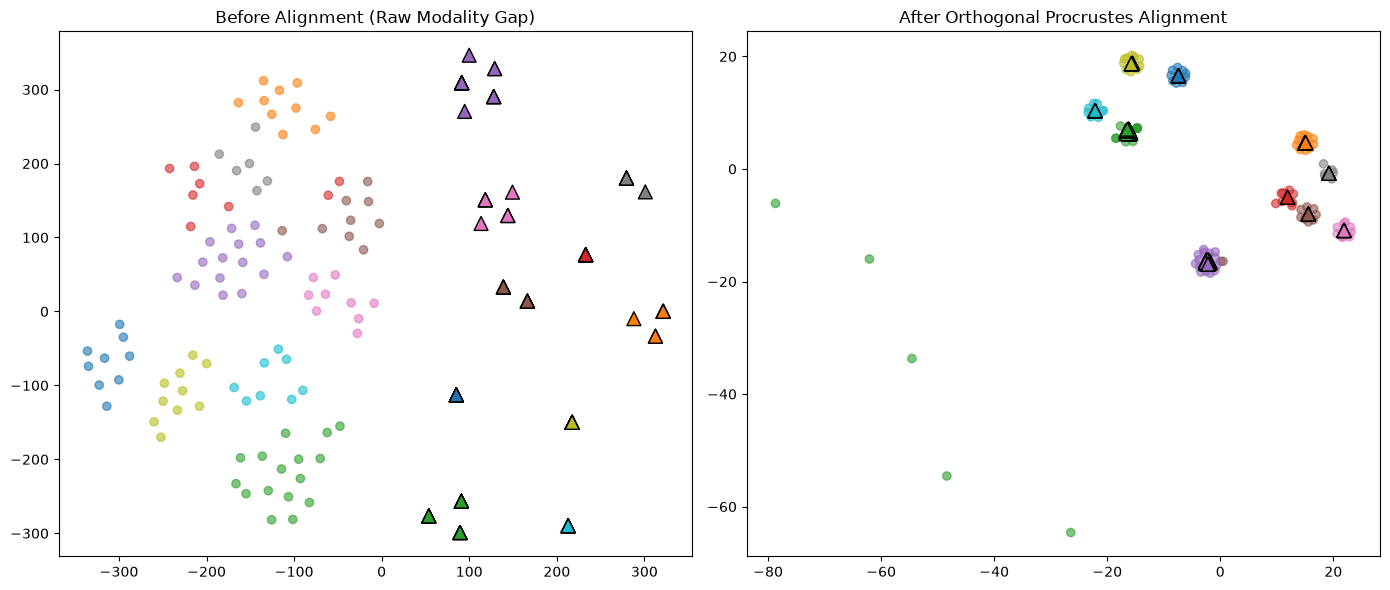


Evaluating Zero-Shot Accuracy AFTER Alignment on full 8,000 image test set...


Aligned Inference: 100%|██████████| 63/63 [00:14<00:00,  4.20it/s]

Aligned Zero-Shot Accuracy: 96.74%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes
from torch.utils.data import Subset

# 1. Extract 100 image-text pairs for the alignment
num_samples = 100
np.random.seed(42) # Fixed seed for reproducibility
subset_indices = np.random.choice(len(stl10_test), num_samples, replace=False)
subset = Subset(stl10_test, subset_indices)
subset_loader = DataLoader(subset, batch_size=100, shuffle=False)

images, labels_100 = next(iter(subset_loader))
images = images.to(device)

with torch.no_grad():
    # Image embeddings
    image_embeddings = model.encode_image(images)
    image_embeddings /= image_embeddings.norm(dim=-1, keepdim=True)
    image_embeddings = image_embeddings.cpu().numpy()
    
    # Text embeddings for the exact true classes of those 100 images
    best_template = "a photo of a {}."
    texts = [best_template.format(classes[lbl]) for lbl in labels_100]
    tokens = clip.tokenize(texts).to(device)
    text_embeddings = model.encode_text(tokens)
    text_embeddings /= text_embeddings.norm(dim=-1, keepdim=True)
    text_embeddings = text_embeddings.cpu().numpy()

# 2. Calculate initial modality gap (distance between centroids)
image_centroid_before = image_embeddings.mean(axis=0)
text_centroid_before = text_embeddings.mean(axis=0)
gap_before = np.linalg.norm(image_centroid_before - text_centroid_before)
print(f"Modality Gap (Centroid Distance) BEFORE alignment: {gap_before:.4f}")

# 3. Orthogonal Procrustes Alignment
# Find rotation matrix R that best maps image_embeddings to text_embeddings
R, scale = orthogonal_procrustes(image_embeddings, text_embeddings)
aligned_image_embeddings = image_embeddings @ R

# Calculate new gap
image_centroid_after = aligned_image_embeddings.mean(axis=0)
gap_after = np.linalg.norm(image_centroid_after - text_centroid_before) 
print(f"Modality Gap (Centroid Distance) AFTER alignment: {gap_after:.4f}")

# 4. t-SNE Visualization
# Combine data for t-SNE so they share the exact same 2D projection space
all_embeddings_before = np.vstack([image_embeddings, text_embeddings])
all_embeddings_after = np.vstack([aligned_image_embeddings, text_embeddings])

tsne_before = TSNE(n_components=2, random_state=42, perplexity=15).fit_transform(all_embeddings_before)
tsne_after = TSNE(n_components=2, random_state=42, perplexity=15).fit_transform(all_embeddings_after)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

img_x_b, img_y_b = tsne_before[:100, 0], tsne_before[:100, 1]
txt_x_b, txt_y_b = tsne_before[100:, 0], tsne_before[100:, 1]

img_x_a, img_y_a = tsne_after[:100, 0], tsne_after[:100, 1]
txt_x_a, txt_y_a = tsne_after[100:, 0], tsne_after[100:, 1]

cmap = plt.get_cmap('tab10')
colors = [cmap(l) for l in labels_100.numpy()]

# Plot Before
ax1.scatter(img_x_b, img_y_b, c=colors, marker='o', alpha=0.6, label='Image')
ax1.scatter(txt_x_b, txt_y_b, c=colors, marker='^', s=100, edgecolors='k', label='Text')
ax1.set_title("Before Alignment (Raw Modality Gap)")

# Plot After
ax2.scatter(img_x_a, img_y_a, c=colors, marker='o', alpha=0.6, label='Image')
ax2.scatter(txt_x_a, txt_y_a, c=colors, marker='^', s=100, edgecolors='k', label='Text')
ax2.set_title("After Orthogonal Procrustes Alignment")

plt.tight_layout()
plt.savefig('../report/figures/task3_modality_gap.png', dpi=300)
plt.show()

# 5. Evaluate Zero-Shot Accuracy AFTER Alignment on the FULL dataset
print("\nEvaluating Zero-Shot Accuracy AFTER Alignment on full 8,000 image test set...")
correct = 0
total = 0

all_class_texts = [best_template.format(c) for c in classes]
all_class_tokens = clip.tokenize(all_class_texts).to(device)

with torch.no_grad():
    full_text_embeddings = model.encode_text(all_class_tokens)
    full_text_embeddings /= full_text_embeddings.norm(dim=-1, keepdim=True)
    
    for images, batch_labels in tqdm(test_loader, desc="Aligned Inference"):
        images = images.to(device)
        batch_labels = batch_labels.to(device)
        
        img_feats = model.encode_image(images)
        img_feats /= img_feats.norm(dim=-1, keepdim=True)
        
        # Apply the learned rotation R to the image features
        R_tensor = torch.tensor(R, device=device, dtype=img_feats.dtype)
        aligned_img_feats = img_feats @ R_tensor
        
        similarity = (100.0 * aligned_img_feats @ full_text_embeddings.T).softmax(dim=-1)
        preds = similarity.argmax(dim=-1)
        
        correct += (preds == batch_labels).sum().item()
        total += images.size(0)
        
print(f"Aligned Zero-Shot Accuracy: {(correct/total)*100:.2f}%")

Generating predictions for Confusion Matrix...


Inference: 100%|██████████| 63/63 [00:15<00:00,  4.07it/s]


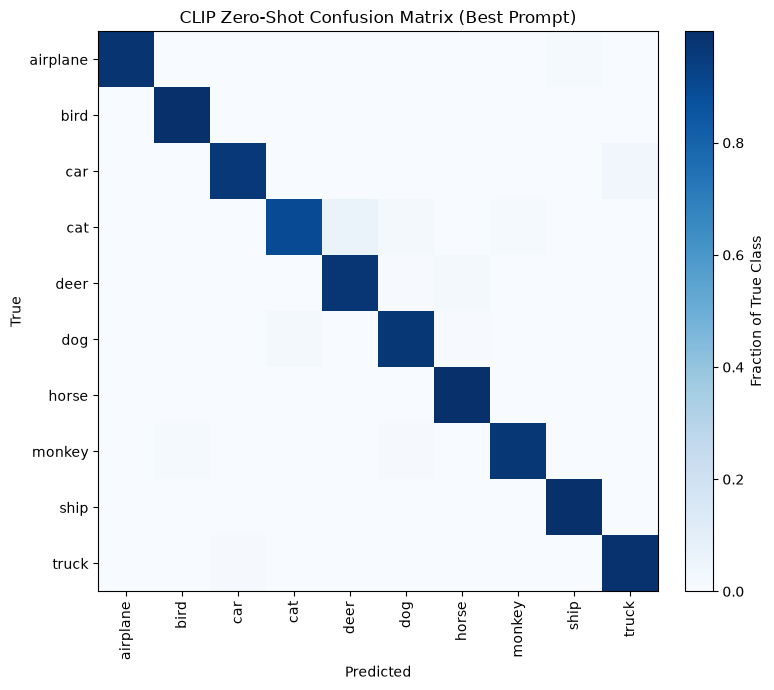

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

best_template = "a photo of a {}."
texts = [best_template.format(c) for c in classes]
tokens = clip.tokenize(texts).to(device)

all_preds = []
all_labels = []

print("Generating predictions for Confusion Matrix...")
with torch.no_grad():
    text_features = model.encode_text(tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    
    for images, labels in tqdm(test_loader, desc="Inference"):
        images = images.to(device)
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        preds = similarity.argmax(dim=-1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute and normalize Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.matshow(cm_normalized, cmap='Blues')
fig.colorbar(cax, fraction=0.046, pad=0.04, label='Fraction of True Class')

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('CLIP Zero-Shot Confusion Matrix (Best Prompt)')
ax.xaxis.set_ticks_position('bottom')

plt.tight_layout()
plt.savefig('../report/figures/task3_confusion_matrix.png', dpi=300)
plt.show()